In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("data/kenya.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


In [4]:
df = df.replace(-999, np.nan)

In [3]:
df["Country"] = "Kenya"
df.head()
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


The dataset includes 4,108 observations from 2015 to 2026, providing a consistent multi-year record of climate conditions.The average temperature (T2M) is about 20.4°C, indicating a moderate climate. Maximum temperatures average 27.8°C, while minimum temperatures average 14.7°C, showing a noticeable but not extreme variation between daytime and nighttime conditions.Precipitation has a low mean (1.47) and median (0.38), indicating that most days experience little or no rainfall. However, the standard deviation (3.18) is relatively large compared to the mean, suggesting a right-skewed distribution with occasional heavier rainfall events.Humidity averages around 65.8%, indicating a moderately humid environment. The range (28% to 73% for most values) shows some variability, but overall conditions remain relatively stable compared to more extreme climates.Average wind speed is about 3.06 m/s, with maximum values around 4.38 m/s, indicating moderate and fairly stable wind conditions. The variability is limited, suggesting no frequent extreme wind events.

In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

In [6]:
df["Month"] = df["DATE"].dt.month

In [7]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

no missing values

In [8]:
from scipy.stats import zscore

cols = ["T2M","T2M_MAX","T2M_MIN","PRECTOTCORR","RH2M","WS2M"]

z = df[cols].apply(zscore)
outliers = (abs(z) > 3)

outliers.sum()
outlier_count = outliers.any(axis=1).sum()
print("Number of rows with |Z| > 3:", outlier_count)

Number of rows with |Z| > 3: 116


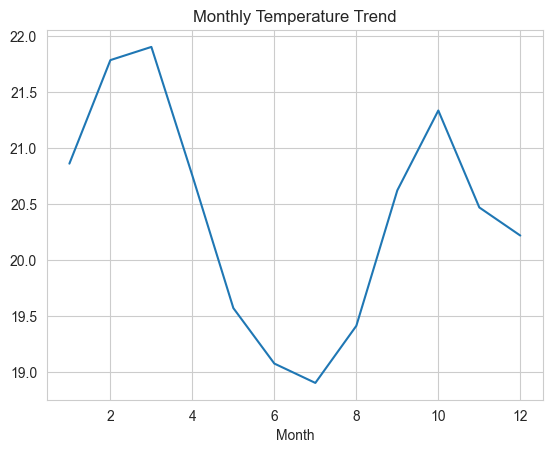

In [9]:
df.groupby("Month")["T2M"].mean().plot()
plt.title("Monthly Temperature Trend")
plt.show()

3rd month is the hottest month
6th month is the coolest month.

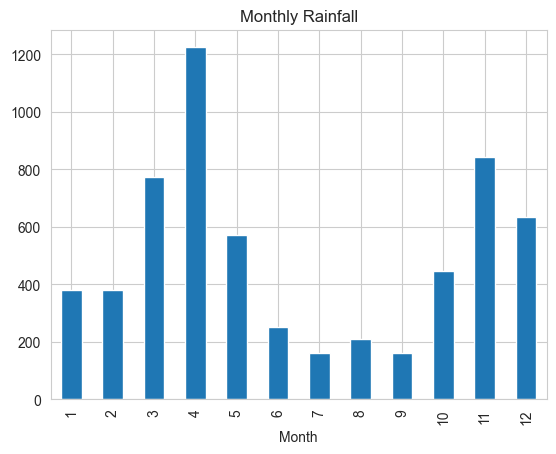

In [10]:
df.groupby("Month")["PRECTOTCORR"].sum().plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

The 4th month is the pick rainy season.

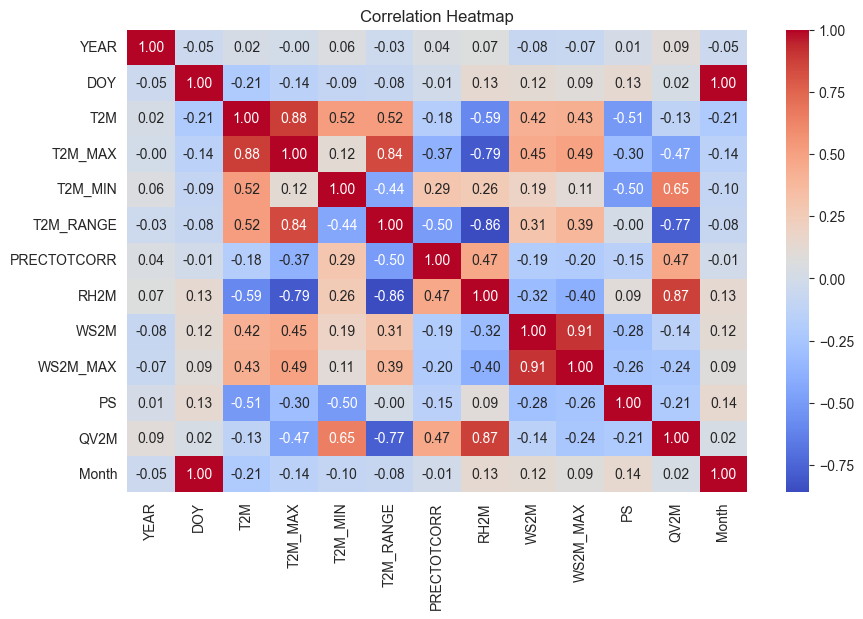

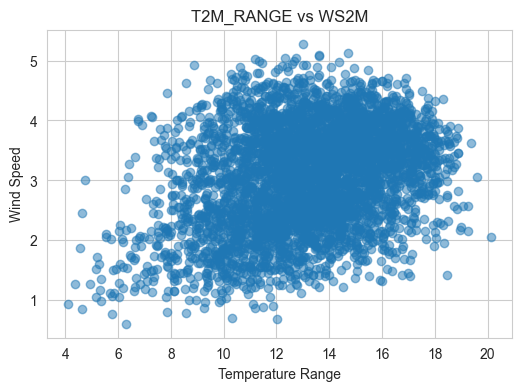

DOY    Month       0.996557
Month  DOY         0.996557
WS2M   WS2M_MAX    0.911457
dtype: float64


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.show()
corr_unstacked = corr.abs().unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1]  # remove self-correlation
top_3 = corr_unstacked.sort_values(ascending=False).head(3)
print(top_3)

DOY and Month (r ≈ 0.9966)
This is an almost perfect positive correlation.Day of Year (DOY) and Month represent the same time progression.WS2M and WS2M_MAX (r ≈ 0.9115) this suggests stable wind conditions, where stronger wind periods affect both average and maximum speeds similarly.

In [ ]:
plt.scatter(df["T2M"], df["RH2M"])
plt.title("Temperature vs Humidity")
plt.show()

In [11]:
df.to_csv("data/kenya_clean.csv", index=False)

# Kenya Climate Data EDA

This notebook explores climate patterns in kenya using NASA dataset data.  
